# 🧹 Data Cleaning - Telco Customer Churn

**Objective:** Clean and prepare the raw dataset for feature engineering and modeling.

**Tasks:**
- Handle missing values
- Fix data types
- Remove duplicates
- Handle inconsistencies
- Validate data quality

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load Raw Dataset

In [2]:
# Load the raw dataset
df = pd.read_csv('../data/raw/telco_churn.csv')

print(f"Original dataset shape: {df.shape}")
print(f"Columns: {df.shape[1]}")
print(f"Rows: {df.shape[0]:,}")

Original dataset shape: (7043, 21)
Columns: 21
Rows: 7,043


In [3]:
# Display first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Fix Data Types

In [5]:
# Check TotalCharges data type (often stored as object/string)
print("\n🔍 Checking TotalCharges data type...")
print(f"Current dtype: {df['TotalCharges'].dtype}")
print(f"Sample values: {df['TotalCharges'].head(10).tolist()}")


🔍 Checking TotalCharges data type...
Current dtype: object
Sample values: ['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95']


In [6]:
# Identify non-numeric values in TotalCharges
if df['TotalCharges'].dtype == 'object':
    print("\n⚠️ TotalCharges is stored as object (string)")
    
    # Try to convert to numeric and identify issues
    df['TotalCharges_original'] = df['TotalCharges'].copy()
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    
    # Find rows that couldn't be converted
    problematic_rows = df[df['TotalCharges'].isna() & df['TotalCharges_original'].notna()]
    
    if len(problematic_rows) > 0:
        print(f"\n⚠️ Found {len(problematic_rows)} rows with non-numeric TotalCharges:")
        print(problematic_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges_original']].head())
    
    # Look for empty strings
    empty_count = (df['TotalCharges_original'] == ' ').sum() + (df['TotalCharges_original'] == '').sum()
    print(f"\n🔍 Empty/whitespace values in TotalCharges: {empty_count}")
    
    # Drop the temporary column
    df.drop('TotalCharges_original', axis=1, inplace=True)


⚠️ TotalCharges is stored as object (string)

⚠️ Found 11 rows with non-numeric TotalCharges:
      customerID  tenure  MonthlyCharges TotalCharges_original
488   4472-LVYGI       0           52.55                      
753   3115-CZMZD       0           20.25                      
936   5709-LVOEQ       0           80.85                      
1082  4367-NUYAO       0           25.75                      
1340  1371-DWPAZ       0           56.05                      

🔍 Empty/whitespace values in TotalCharges: 11


In [7]:
# Convert SeniorCitizen to Yes/No for consistency
print("\n🔄 Converting SeniorCitizen from 0/1 to No/Yes...")
print(f"Before: {df['SeniorCitizen'].unique()}")

df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print(f"After: {df['SeniorCitizen'].unique()}")
print("✅ SeniorCitizen converted to categorical")


🔄 Converting SeniorCitizen from 0/1 to No/Yes...
Before: [0 1]
After: ['No' 'Yes']
✅ SeniorCitizen converted to categorical


## 4. Handle Missing Values

In [8]:
# Check for missing values
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Count', ascending=False)

print("\n🔍 Missing Values Summary:")
print("="*60)
print(missing_summary[missing_summary['Missing_Count'] > 0])

total_missing = missing_summary['Missing_Count'].sum()
print(f"\nTotal missing values: {total_missing}")


🔍 Missing Values Summary:
                    Column  Missing_Count  Missing_Percentage
TotalCharges  TotalCharges             11                0.16

Total missing values: 11


In [9]:
# Strategy for handling missing TotalCharges
if df['TotalCharges'].isna().sum() > 0:
    print("\n📊 Analyzing missing TotalCharges...")
    
    # Check tenure for rows with missing TotalCharges
    missing_total_charges = df[df['TotalCharges'].isna()]
    print(f"\nRows with missing TotalCharges: {len(missing_total_charges)}")
    print(f"Tenure distribution for missing values:")
    print(missing_total_charges['tenure'].value_counts().sort_index())
    
    # Strategy: For tenure 0, TotalCharges should be 0
    # For others, impute with MonthlyCharges * tenure
    print("\n🔧 Imputation Strategy:")
    print("   • tenure = 0 → TotalCharges = 0")
    print("   • tenure > 0 → TotalCharges = MonthlyCharges * tenure")
    
    # Apply imputation
    mask = df['TotalCharges'].isna()
    df.loc[mask, 'TotalCharges'] = df.loc[mask, 'MonthlyCharges'] * df.loc[mask, 'tenure']
    
    print(f"\n✅ Imputed {mask.sum()} missing TotalCharges values")
    print(f"Remaining missing: {df['TotalCharges'].isna().sum()}")


📊 Analyzing missing TotalCharges...

Rows with missing TotalCharges: 11
Tenure distribution for missing values:
tenure
0    11
Name: count, dtype: int64

🔧 Imputation Strategy:
   • tenure = 0 → TotalCharges = 0
   • tenure > 0 → TotalCharges = MonthlyCharges * tenure

✅ Imputed 11 missing TotalCharges values
Remaining missing: 0


In [10]:
# Final check for any remaining missing values
remaining_missing = df.isnull().sum().sum()
if remaining_missing > 0:
    print(f"\n⚠️ Still have {remaining_missing} missing values")
    print(df.isnull().sum()[df.isnull().sum() > 0])
    
    # Decision: Drop rows with any remaining missing values
    print("\n🗑️ Dropping rows with remaining missing values...")
    df_before = len(df)
    df.dropna(inplace=True)
    df_after = len(df)
    print(f"Dropped {df_before - df_after} rows")
else:
    print("\n✅ No missing values remaining!")


✅ No missing values remaining!


## 5. Handle Duplicates

In [11]:
# Check for duplicate rows
print("\n🔍 Checking for duplicates...")
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"\n🗑️ Removing {duplicates} duplicate rows...")
    df.drop_duplicates(inplace=True)
    print("✅ Duplicates removed")
else:
    print("✅ No duplicates found")


🔍 Checking for duplicates...
Duplicate rows: 0
✅ No duplicates found


In [12]:
# Check for duplicate customer IDs
if 'customerID' in df.columns:
    duplicate_ids = df['customerID'].duplicated().sum()
    print(f"\n🔍 Duplicate customer IDs: {duplicate_ids}")
    
    if duplicate_ids > 0:
        print("⚠️ Found duplicate customer IDs!")
        print(df[df['customerID'].duplicated(keep=False)].sort_values('customerID').head(10))
    else:
        print("✅ All customer IDs are unique")


🔍 Duplicate customer IDs: 0
✅ All customer IDs are unique


## 6. Data Validation & Consistency Checks

In [13]:
# Check for logical inconsistencies
print("\n🔍 Validation Checks:")
print("="*60)

# 1. TotalCharges should be >= MonthlyCharges for tenure > 0
inconsistent_charges = df[(df['tenure'] > 0) & (df['TotalCharges'] < df['MonthlyCharges'])]
print(f"\n1. TotalCharges < MonthlyCharges for tenure > 0: {len(inconsistent_charges)} rows")
if len(inconsistent_charges) > 0:
    print("   Sample:")
    print(inconsistent_charges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head())

# 2. Tenure = 0 should have specific characteristics
tenure_zero = df[df['tenure'] == 0]
print(f"\n2. Customers with tenure = 0: {len(tenure_zero)} rows")
if len(tenure_zero) > 0:
    print(f"   TotalCharges range: {tenure_zero['TotalCharges'].min()} - {tenure_zero['TotalCharges'].max()}")

# 3. Check negative values in numerical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print("\n3. Negative values check:")
for col in numerical_cols:
    negative_count = (df[col] < 0).sum()
    print(f"   {col}: {negative_count} negative values")

# 4. Check for outliers using IQR method
print("\n4. Outlier detection (IQR method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"   {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")


🔍 Validation Checks:

1. TotalCharges < MonthlyCharges for tenure > 0: 0 rows

2. Customers with tenure = 0: 11 rows
   TotalCharges range: 0.0 - 0.0

3. Negative values check:
   tenure: 0 negative values
   MonthlyCharges: 0 negative values
   TotalCharges: 0 negative values

4. Outlier detection (IQR method):
   tenure: 0 outliers (0.00%)
   MonthlyCharges: 0 outliers (0.00%)
   TotalCharges: 0 outliers (0.00%)


In [14]:
# Check categorical value consistency
print("\n🔍 Categorical Values Consistency:")
print("="*60)

categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')

for col in categorical_cols[:10]:  # Check first 10
    print(f"\n{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Values: {df[col].unique().tolist()}")


🔍 Categorical Values Consistency:

gender:
  Unique values: 2
  Values: ['Female', 'Male']

SeniorCitizen:
  Unique values: 2
  Values: ['No', 'Yes']

Partner:
  Unique values: 2
  Values: ['Yes', 'No']

Dependents:
  Unique values: 2
  Values: ['No', 'Yes']

PhoneService:
  Unique values: 2
  Values: ['No', 'Yes']

MultipleLines:
  Unique values: 3
  Values: ['No phone service', 'No', 'Yes']

InternetService:
  Unique values: 3
  Values: ['DSL', 'Fiber optic', 'No']

OnlineSecurity:
  Unique values: 3
  Values: ['No', 'Yes', 'No internet service']

OnlineBackup:
  Unique values: 3
  Values: ['Yes', 'No', 'No internet service']

DeviceProtection:
  Unique values: 3
  Values: ['No', 'Yes', 'No internet service']


## 7. Final Data Quality Report

In [15]:
print("\n" + "="*70)
print("📋 DATA CLEANING SUMMARY")
print("="*70)

print("\n✅ COMPLETED TASKS:")
print("   • Fixed TotalCharges data type (object → float)")
print("   • Converted SeniorCitizen (0/1 → No/Yes)")
print("   • Handled missing values")
print("   • Removed duplicates")
print("   • Validated data consistency")

print("\n📊 FINAL DATASET:")
print(f"   • Shape: {df.shape}")
print(f"   • Missing values: {df.isnull().sum().sum()}")
print(f"   • Duplicates: {df.duplicated().sum()}")
print(f"   • Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "="*70)


📋 DATA CLEANING SUMMARY

✅ COMPLETED TASKS:
   • Fixed TotalCharges data type (object → float)
   • Converted SeniorCitizen (0/1 → No/Yes)
   • Handled missing values
   • Removed duplicates
   • Validated data consistency

📊 FINAL DATASET:
   • Shape: (7043, 21)
   • Missing values: 0
   • Duplicates: 0
   • Memory usage: 7.76 MB



## 8. Visualize Data Quality Improvements

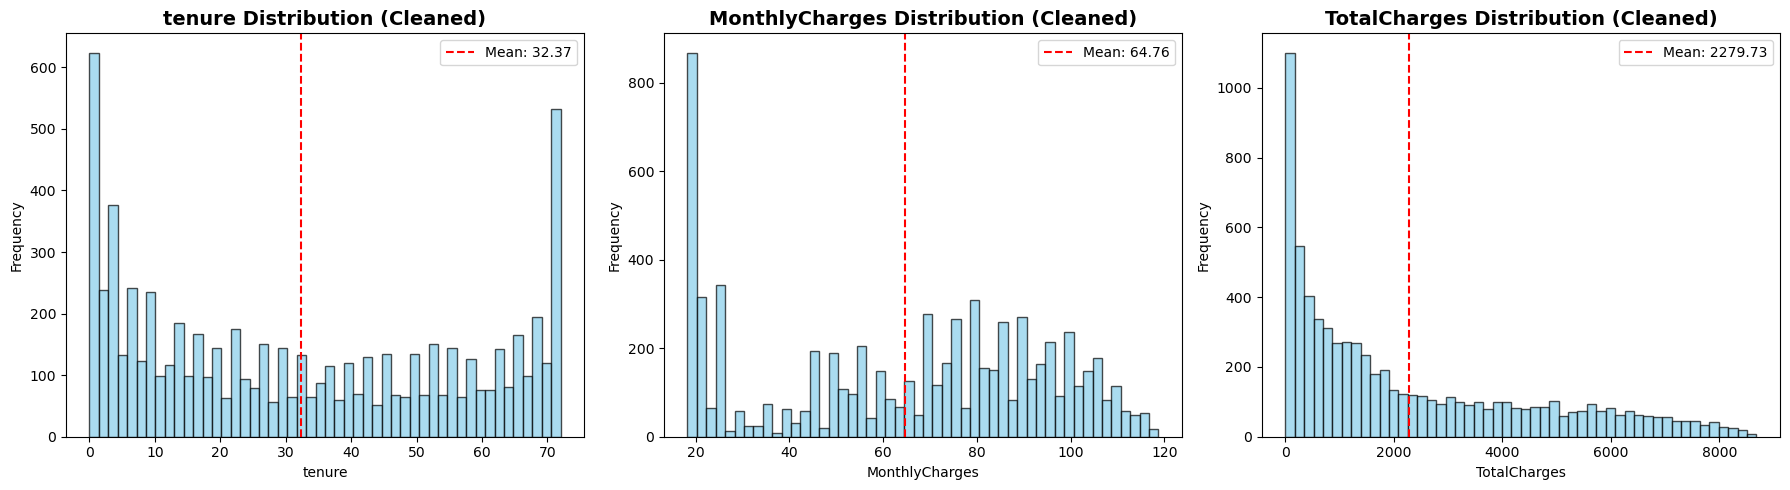

In [16]:
# Distribution comparison for numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[i].set_title(f'{col} Distribution (Cleaned)', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

## 9. Save Cleaned Dataset

In [17]:
# Create artifacts/data directory if it doesn't exist
import os
os.makedirs('../artifacts/data', exist_ok=True)

# Save cleaned dataset
output_path = '../artifacts/data/telco_churn_cleaned.csv'
df.to_csv(output_path, index=False)

print(f"\n✅ Cleaned dataset saved to: {output_path}")
print(f"   File size: {os.path.getsize(output_path) / 1024:.2f} KB")


✅ Cleaned dataset saved to: ../artifacts/data/telco_churn_cleaned.csv
   File size: 964.00 KB


In [18]:
# Verify saved file
df_verify = pd.read_csv(output_path)
print(f"\n🔍 Verification:")
print(f"   Loaded shape: {df_verify.shape}")
print(f"   Original shape: {df.shape}")
print(f"   Match: {df_verify.shape == df.shape}")

if df_verify.shape == df.shape:
    print("\n✅ File saved and verified successfully!")
else:
    print("\n⚠️ Warning: Shapes don't match!")


🔍 Verification:
   Loaded shape: (7043, 21)
   Original shape: (7043, 21)
   Match: True

✅ File saved and verified successfully!
